# Data Understanding

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv(r"..\data\raw\online_retail_II.csv")

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.shape

(1067371, 8)

In [7]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB


In [ ]:
# Missing Value Analysis

missing = df.isnull().sum()

missing_perc = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing values': missing,
    'Percentage': missing_perc
})

missing_df.sort_values(
    by = 'Percentage',
    ascending=False
)

,Missing values,Percentage
Customer ID,243007,22.766873
Description,4382,0.410541
StockCode,0,0.000000
Invoice,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000


In [ ]:
# Duplicate Analysis

duplicates = df.duplicated().sum()

duplicates

np.int64(34335)

In [ ]:
# Statistical Summary

df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [ ]:
# Convert Date Column

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
 

In [ ]:
# Create Revenue Feature

df['Revenue'] = df['Quantity'] * df['Price']

df[['Quantity', 'Price', 'Revenue']].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


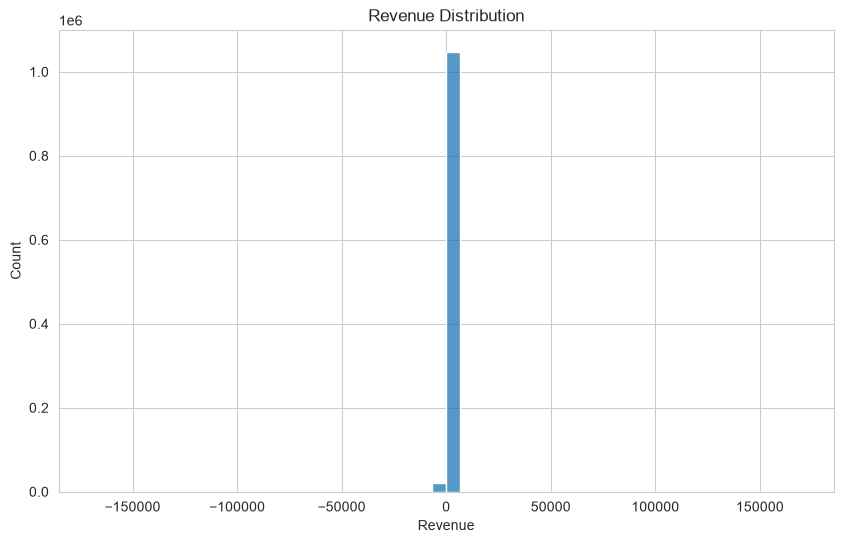

In [ ]:
# Revenue Distribution

plt.figure(figsize=(10,6))

sns.histplot(df['Revenue'], bins=50)

plt.title("Revenue Distribution")
plt.show()

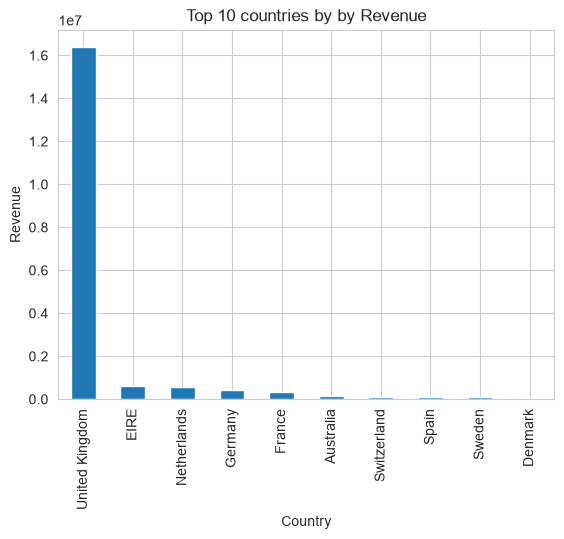

In [ ]:
# Top Countries by Revenue

country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.Figure(figsize=(10,6))

country_revenue.plot(kind='bar')

plt.title("Top 10 countries by by Revenue")
plt.ylabel("Revenue")

plt.show()

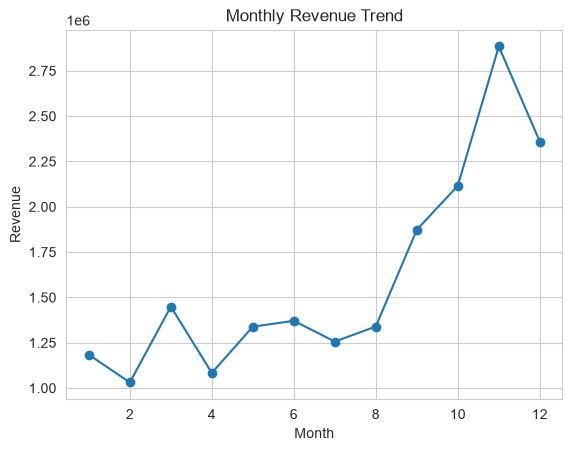

In [ ]:
# Monthly Revenue Trend

monthly_revenue = (
    df.groupby('Month')['Revenue']
    .sum()
)

plt.Figure(figsize=(10, 6))

monthly_revenue.plot(marker='o')


plt.title("Monthly Revenue Trend")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [ ]:
# Top Customers

top_customers = (
    df.groupby('Customer ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer ID
18102.0    598215.22
14646.0    523342.07
14156.0    296564.69
14911.0    270248.53
17450.0    233579.39
13694.0    190825.52
17511.0    171885.98
12415.0    143269.29
16684.0    141502.25
15061.0    136391.48
Name: Revenue, dtype: float64

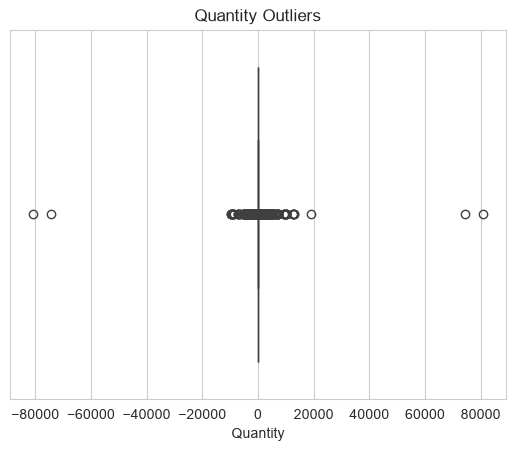

In [ ]:
# Outlier Detection

plt.Figure(figsize=(10,6))

sns.boxplot(x=df['Quantity'])

plt.title("Quantity Outliers")

plt.show()

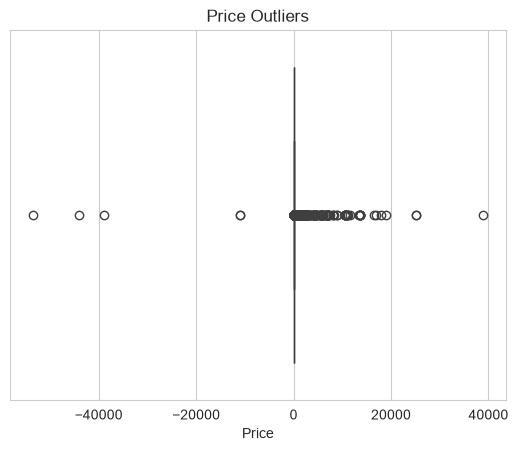

In [30]:
plt.Figure(figsize=(10,6))

sns.boxplot(x=df['Price'])

plt.title("Price Outliers")

plt.show()

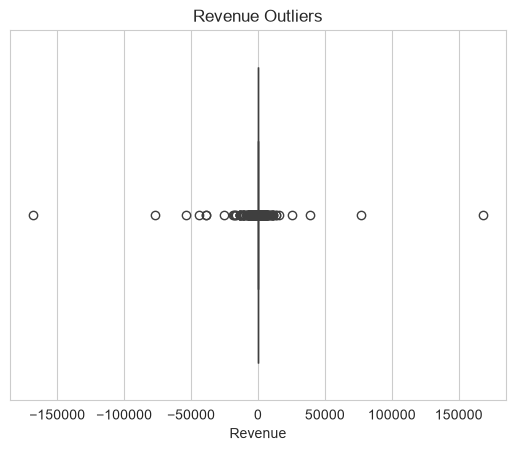

In [31]:
plt.Figure(figsize=(10,6))

sns.boxplot(x=df['Revenue'])

plt.title("Revenue Outliers")

plt.show()

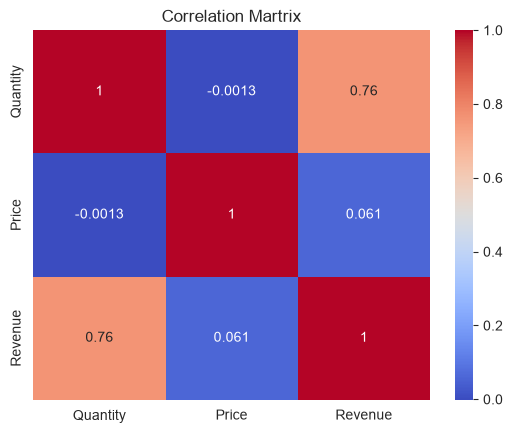

In [ ]:
# Correlation Analysis

numerical_cols = ['Quantity', 'Price', 'Revenue']

corr = df[numerical_cols].corr()

plt.Figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Martrix")

plt.show()

1. Dataset contains over 1 million transactions.

2. Approximately 22.8% of records have missing Customer IDs.

3. Around 34,335 duplicate transactions exist.

4. Dataset contains returns/cancellations represented by negative quantities.

5. Extreme outliers exist in Quantity, Price, and Revenue.

6. Revenue distribution is highly right-skewed.

7. United Kingdom contributes the majority of total revenue.

8. Significant seasonality exists, with revenue peaking during Q4.

9. Revenue is strongly influenced by Quantity purchased.

10. Customer purchasing behavior is highly heterogeneous, making segmentation essential.